In [31]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
import numpy as np
import matplotlib.pyplot as plt

In [4]:
housing = fetch_california_housing(as_frame=True) # Returns data_frame instead of numpy array
df = housing.frame
df.isnull().any()

MedInc         False
HouseAge       False
AveRooms       False
AveBedrms      False
Population     False
AveOccup       False
Latitude       False
Longitude      False
MedHouseVal    False
dtype: bool

In [37]:
X = df[["MedInc"]]
y = df["MedHouseVal"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [38]:
regr = LinearRegression()
regr.fit(X_train, y_train)
print(f"R^2 = {regr.score(X_test, y_test):.2f}")

R^2 = 0.48


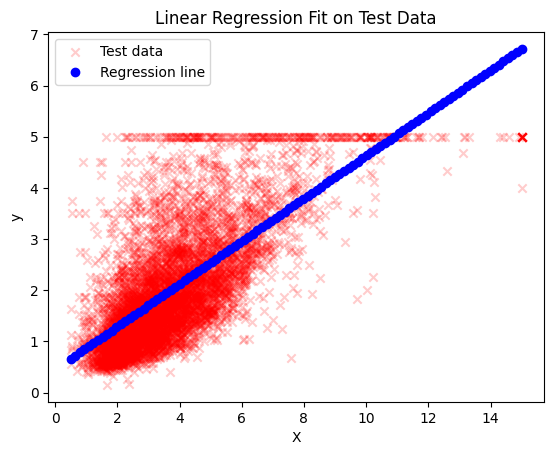

In [40]:
regr_x = np.linspace(X_test.min(), X_test.max(), 100)
regr_y = regr.coef_[0] * regr_x + regr.intercept_

plt.scatter(X_test, y_test, marker="x", alpha=0.2, c="red", label="Test data")
plt.plot(regr_x, regr_y, 'bo', label="Regression line")

plt.title("Linear Regression Fit on Test Data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

plt.show()

In [30]:
X = df[['MedInc', 'HouseAge', 'AveRooms']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
regr = LinearRegression()
regr.fit(X_train, y_train)
print(f"R^2 = {regr.score(X_test, y_test):.2f}")

R^2 = 0.51


In [32]:
model = TransformedTargetRegressor(LinearRegression(),
                                   transformer=StandardScaler())
model.fit(X_train, y_train)

,regressor,LinearRegression()
,transformer,StandardScaler()
,func,None
,inverse_func,None
,check_inverse,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
,copy,True


In [33]:
model.score(X_test, y_test)

0.5112656355371213

In [34]:
# Pipeline for X
regressor = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])

# Scale y as well
model = TransformedTargetRegressor(
    regressor=regressor,
    transformer=StandardScaler()
)

model.fit(X_train, y_train)
model.score(X_test, y_test)

0.5112656355371212